Tolerance: 0.01
Iterations: 3
Error: 0.00019613929759589816
Solution: [ 3.0000225  -2.50000266  6.99998104] 

Tolerance: 1e-05
Iterations: 5
Error: 3.1931009248486043e-07
Solution: [ 2.99999991 -2.50000001  7.00000002] 

Tolerance: 1e-08
Iterations: 7
Error: 9.443570026197372e-10
Solution: [ 3.  -2.5  7. ] 

Total Iterations:  7 

Final Solution:  [ 3.  -2.5  7. ] 



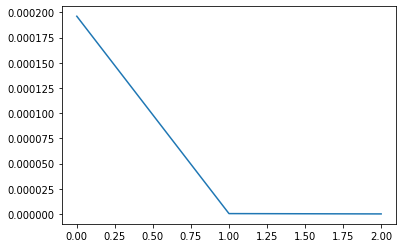

In [2]:
#jacobi
import time 
import math
import numpy as np
import matplotlib.pyplot as plt

def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
# Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k
        x = x_new
#       print("X is: ", x)
    return x, max_iterations

#Example usage
jacobi_tolerance = [10e-3,10e-6,10e-9]
Error_List = []
x_axis = []

A = np.array([
    [3,   -0.1, -0.2],
    [0.1,  7,   -0.3],
    [0.3, -0.2, 10] ], dtype=float)

b = np.array([7.85, -19.3, 71.4], dtype=float)

for i in range(len(jacobi_tolerance)):
    x0 = np.zeros_like(b)
    tol = jacobi_tolerance[i]
    
    solution, iterations = jacobi(A, b, x0, tol, 100)
    Abs_Error = np.linalg.norm(np.dot(A, solution) - b)
    
    x_axis.append(i)
    Error_List.append(Abs_Error)
    print(f"Tolerance: {tol}")
    print(f"Iterations: {iterations}")
    print(f"Error: {Abs_Error}") 
    print(f"Solution: {solution} \n")
    
print("Total Iterations: ", iterations, "\n")
print("Final Solution: ", solution, "\n")

plt.plot(x_axis, Error_List)

Tolerance: 0.01
Iterations: 2
Error: 0.0001288603810423038
Solution: [ 3.0000319  -2.49998799  6.99999928] 

Tolerance: 1e-05
Iterations: 4
Error: 6.721731598865339e-09
Solution: [ 3.  -2.5  7. ] 

Tolerance: 1e-08
Iterations: 5
Error: 3.892709160094153e-11
Solution: [ 3.  -2.5  7. ] 

Total Iterations:  5 

Final Solution:  [ 3.  -2.5  7. ] 



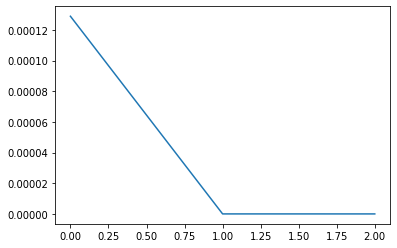

In [3]:
#gauss-Seidel
import numpy as np
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        
# Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k
        x = x_new
#        print("X is: ", x)

    return x, max_iterations

#Example usage
gauss_Seidel_tolerance = [10e-3,10e-6,10e-9]
Error_List = []
x_axis = []

A = np.array([
    [3,   -0.1, -0.2],
    [0.1,  7,   -0.3],
    [0.3, -0.2, 10] ], dtype=float)

b = np.array([7.85, -19.3, 71.4], dtype=float)

for i in range(len(gauss_Seidel_tolerance)):
    x0 = np.zeros_like(b)
    tol = gauss_Seidel_tolerance[i]
    
    solution, iterations = gauss_seidel(A, b, x0, tol, 100)
    Abs_Error = np.linalg.norm(np.dot(A, solution) - b)
    
    x_axis.append(i)
    Error_List.append(Abs_Error)
    print(f"Tolerance: {tol}")
    print(f"Iterations: {iterations}")
    print(f"Error: {Abs_Error}") 
    print(f"Solution: {solution} \n")

print("Total Iterations: ", iterations, "\n")
print("Final Solution: ", solution, "\n")

plt.plot(x_axis, Error_List)
